<div style="
  text-align: center;
  font-size: 2.5em;
  font-weight: bold;
  color: #333;
  padding: 20px;
  border: 2px solid #f1c40f;
  border-radius: 12px;
  width: fit-content;
  margin: 40px auto;
  background-color: #fff8b0;
  box-shadow: 0 0 10px rgba(0,0,0,0.1);
">
  Scenario 1
</div>


In [1]:
import threading
import time
from collections import defaultdict

class Acceptor:
    def __init__(self, id):
        self.id = id
        self.promised_id = -1
        self.accepted_id = -1
        self.accepted_value = None

    def receive_prepare(self, proposal_id):
        print(f"[Acceptor {self.id}] Received PREPARE({proposal_id})")
        if proposal_id > self.promised_id:
            self.promised_id = proposal_id
            print(f"[Acceptor {self.id}] Sending PROMISE({proposal_id})")
            return True, self.accepted_id, self.accepted_value
        else:
            print(f"[Acceptor {self.id}] Rejected PREPARE({proposal_id})")
            return False, None, None

    def receive_accept(self, proposal_id, value):
        print(f"[Acceptor {self.id}] Received ACCEPT({proposal_id}, {value})")
        if proposal_id >= self.promised_id:
            self.promised_id = proposal_id
            self.accepted_id = proposal_id
            self.accepted_value = value
            print(f"[Acceptor {self.id}] Accepted({proposal_id}, {value})")
            return True
        else:
            print(f"[Acceptor {self.id}] Rejected ACCEPT({proposal_id}, {value})")
            return False

class Proposer:
    def __init__(self, id, value, acceptors):
        self.id = id
        self.value = value
        self.acceptors = acceptors

    def run(self):
        proposal_id = self.id * 100  # Unique ID for proposer
        promises = []
        print(f"\n[Proposer] Sending PREPARE({proposal_id}) to all acceptors")
        for a in self.acceptors:
            ok, _, _ = a.receive_prepare(proposal_id)
            if ok:
                promises.append(a)
        
        if len(promises) >= (len(self.acceptors) // 2) + 1:
            print(f"[Proposer] Got majority PROMISEs, sending ACCEPT({proposal_id}, {self.value})")
            for a in promises:
                a.receive_accept(proposal_id, self.value)
        else:
            print("[Proposer] Failed to get majority PROMISEs")

# Simulation
acceptors = [Acceptor(i) for i in range(3)]
proposer = Proposer(id=1, value="42", acceptors=acceptors)

thread = threading.Thread(target=proposer.run)
thread.start()
thread.join()



[Proposer] Sending PREPARE(100) to all acceptors
[Acceptor 0] Received PREPARE(100)
[Acceptor 0] Sending PROMISE(100)
[Acceptor 1] Received PREPARE(100)
[Acceptor 1] Sending PROMISE(100)
[Acceptor 2] Received PREPARE(100)
[Acceptor 2] Sending PROMISE(100)
[Proposer] Got majority PROMISEs, sending ACCEPT(100, 42)
[Acceptor 0] Received ACCEPT(100, 42)
[Acceptor 0] Accepted(100, 42)
[Acceptor 1] Received ACCEPT(100, 42)
[Acceptor 1] Accepted(100, 42)
[Acceptor 2] Received ACCEPT(100, 42)
[Acceptor 2] Accepted(100, 42)


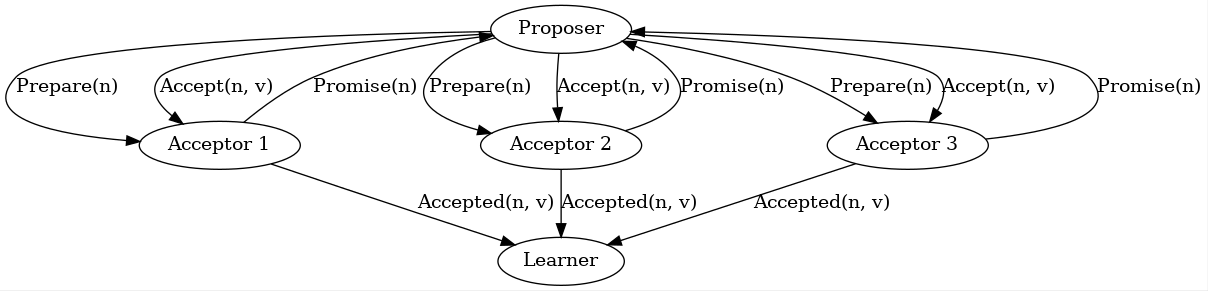

## Scenario 1: Successful Execution Without Failures

In this basic scenario, we assume that there is only **one proposer**, and all **acceptors** are healthy and responsive. There are no node failures, no message delays, and no conflicts. This setup represents the ideal and most straightforward behavior of the Paxos algorithm.

### 🧩 Step-by-Step Breakdown:

#### Step 1: `Prepare(n)` - Proposer Sends Prepare Requests

- The proposer picks a unique proposal number `n` (e.g., `n = 100`) and sends a `Prepare(n)` message to all acceptors.
- This message is like saying: *“Hey, if you haven't promised to a higher number yet, can you promise not to accept anything lower than this?”*

#### Step 2: `Promise(n)` - Acceptors Respond with Promises

- Each acceptor checks the number `n`:
  - If it's greater than any previous number it promised to, it promises not to accept any lower-numbered proposal in the future.
  - It sends back a `Promise(n)` message to the proposer.
  - It may also include info about any previously accepted proposal, if any.
- If the proposer receives a majority (more than half) of promises, it proceeds to the next step.

#### Step 3: `Accept(n, v)` - Proposer Sends Accept Request

- After gathering enough promises, the proposer sends an `Accept(n, v)` message, where `v` is the proposed value (e.g., `"42"`).
- The proposer sends this message only to those acceptors who sent promises.

#### Step 4: `Accepted(n, v)` - Acceptors Accept the Proposal

- Each acceptor checks if `n` is still greater than or equal to any number it already promised to.
- If yes, it accepts the value and sends back an `Accepted(n, v)` message.
- Once a majority of acceptors accept the same value, it is considered *chosen*.

#### Step 5: Learner is Notified

- The learner is informed of the chosen value, either by acceptors directly or by polling them.
- In this scenario, the value `"42"` is successfully chosen as the consensus result.

<div style="
  text-align: center;
  font-size: 2.5em;
  font-weight: bold;
  color: #333;
  padding: 20px;
  border: 2px solid #f1c40f;
  border-radius: 12px;
  width: fit-content;
  margin: 40px auto;
  background-color: #fff8b0;
  box-shadow: 0 0 10px rgba(0,0,0,0.1);
">
  Scenario 2
</div>


In [2]:
import threading

class Acceptor:
    def __init__(self, id, fail=False):
        self.id = id
        self.fail = fail
        self.promised_id = -1
        self.accepted_id = -1
        self.accepted_value = None

    def receive_prepare(self, proposal_id):
        if self.fail:
            print(f"[Acceptor {self.id}] FAILED - No response to PREPARE")
            return False, None, None
        if proposal_id > self.promised_id:
            self.promised_id = proposal_id
            print(f"[Acceptor {self.id}] Promise for proposal {proposal_id}")
            return True, self.accepted_id, self.accepted_value
        return False, None, None

    def receive_accept(self, proposal_id, value):
        if self.fail:
            print(f"[Acceptor {self.id}] FAILED - No response to ACCEPT")
            return False
        if proposal_id >= self.promised_id:
            self.accepted_id = proposal_id
            self.accepted_value = value
            print(f"[Acceptor {self.id}] Accepted value {value} with proposal {proposal_id}")
            return True
        return False

class Proposer:
    def __init__(self, id, value, acceptors):
        self.id = id
        self.value = value
        self.acceptors = acceptors

    def run(self):
        proposal_id = self.id * 100
        promises = []
        print(f"\n[Proposer] Sending PREPARE({proposal_id})")
        for a in self.acceptors:
            ok, _, _ = a.receive_prepare(proposal_id)
            if ok:
                promises.append(a)

        if len(promises) >= (len(self.acceptors) // 2) + 1:
            print("[Proposer] Got majority promises. Sending ACCEPT.")
            for a in promises:
                a.receive_accept(proposal_id, self.value)
        else:
            print("[Proposer] Failed to get majority. Abort.")

# Simulation with 1 failed acceptor
acceptors = [Acceptor(1), Acceptor(2), Acceptor(3, fail=True)]
proposer = Proposer(id=1, value="42", acceptors=acceptors)

thread = threading.Thread(target=proposer.run)
thread.start()
thread.join()



[Proposer] Sending PREPARE(100)
[Acceptor 1] Promise for proposal 100
[Acceptor 2] Promise for proposal 100
[Acceptor 3] FAILED - No response to PREPARE
[Proposer] Got majority promises. Sending ACCEPT.
[Acceptor 1] Accepted value 42 with proposal 100
[Acceptor 2] Accepted value 42 with proposal 100


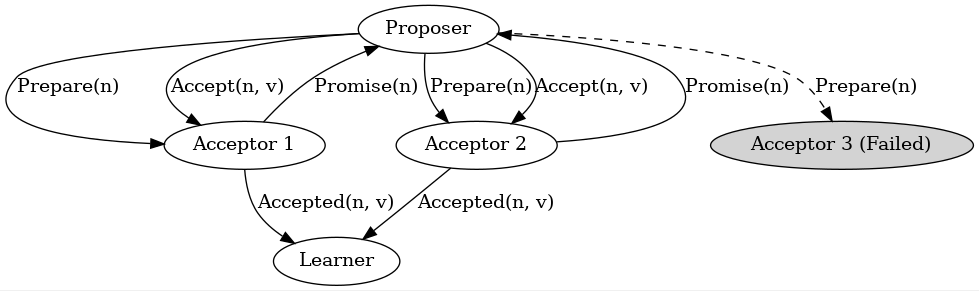

In this scenario, the Paxos algorithm runs in the presence of a partial failure: one of the acceptors (Acceptor 3) is down and does not respond.

#### 🔄 Step-by-step:

1. The proposer sends `Prepare(n)` to all acceptors.
2. Two acceptors respond with `Promise(n)`, but one (A3) fails and does not respond.
3. Since a majority (2 out of 3) have promised, the proposer sends `Accept(n, v)` to the responders.
4. The two acceptors accept the value, and consensus is reached.
5. The learner is informed by the two functioning acceptors.

✅ **Conclusion:**
Paxos can still reach consensus as long as a majority of acceptors are available. The algorithm is fault-tolerant and does not require all nodes to be alive.

<div style="
  text-align: center;
  font-size: 2.5em;
  font-weight: bold;
  color: #333;
  padding: 20px;
  border: 2px solid #f1c40f;
  border-radius: 12px;
  width: fit-content;
  margin: 40px auto;
  background-color: #fff8b0;
  box-shadow: 0 0 10px rgba(0,0,0,0.1);
">
  Scenario 3
</div>


In [6]:
import threading

class Acceptor:
    def __init__(self, id):
        self.id = id
        self.promised_id = -1
        self.accepted_id = -1
        self.accepted_value = None

    def receive_prepare(self, proposal_id):
        if proposal_id > self.promised_id:
            self.promised_id = proposal_id
            print(f"[Acceptor {self.id}] Promise({proposal_id})")
            return True, self.accepted_id, self.accepted_value
        return False, None, None

    def receive_accept(self, proposal_id, value):
        if proposal_id >= self.promised_id:
            self.promised_id = proposal_id
            self.accepted_id = proposal_id
            self.accepted_value = value
            print(f"[Acceptor {self.id}] Accepted({proposal_id}, {value})")
            return True
        return False

class Proposer(threading.Thread):
    def __init__(self, id, value, acceptors):
        super().__init__()
        self.id = id
        self.value = value
        self.acceptors = acceptors

    def run(self):
        proposal_id = self.id * 100
        promises = []
        accepted_info = []

        print(f"\n[Proposer {self.id}] Sending PREPARE({proposal_id})")
        for a in self.acceptors:
            ok, last_accepted_id, last_accepted_value = a.receive_prepare(proposal_id)
            if ok:
                promises.append(a)
                if last_accepted_value is not None:
                    accepted_info.append((last_accepted_id, last_accepted_value))

        if len(promises) >= (len(self.acceptors) // 2) + 1:
            # If any previously accepted value exists, adopt the highest one
            if accepted_info:
                accepted_info.sort(reverse=True)
                chosen_value = accepted_info[0][1]
                print(f"[Proposer {self.id}] Adopting previously accepted value: {chosen_value}")
            else:
                chosen_value = self.value
                print(f"[Proposer {self.id}] No prior accepted value. Using own: {chosen_value}")

            print(f"[Proposer {self.id}] Sending ACCEPT({proposal_id}, {chosen_value})")
            for a in promises:
                a.receive_accept(proposal_id, chosen_value)
        else:
            print(f"[Proposer {self.id}] Not enough promises. Aborting.")

# Simulation
acceptors = [Acceptor(1), Acceptor(2), Acceptor(3)]
p1 = Proposer(id=1, value="42", acceptors=acceptors)
p2 = Proposer(id=2, value="84", acceptors=acceptors)

# Start both concurrently
p1.start()
p2.start()
p1.join()
p2.join()



[Proposer 1] Sending PREPARE(100)
[Acceptor 1] Promise(100)
[Acceptor 2] Promise(100)
[Acceptor 3] Promise(100)
[Proposer 1] No prior accepted value. Using own: 42
[Proposer 1] Sending ACCEPT(100, 42)
[Acceptor 1] Accepted(100, 42)
[Acceptor 2] Accepted(100, 42)
[Acceptor 3] Accepted(100, 42)

[Proposer 2] Sending PREPARE(200)
[Acceptor 1] Promise(200)
[Acceptor 2] Promise(200)
[Acceptor 3] Promise(200)
[Proposer 2] Adopting previously accepted value: 42
[Proposer 2] Sending ACCEPT(200, 42)
[Acceptor 1] Accepted(200, 42)
[Acceptor 2] Accepted(200, 42)
[Acceptor 3] Accepted(200, 42)


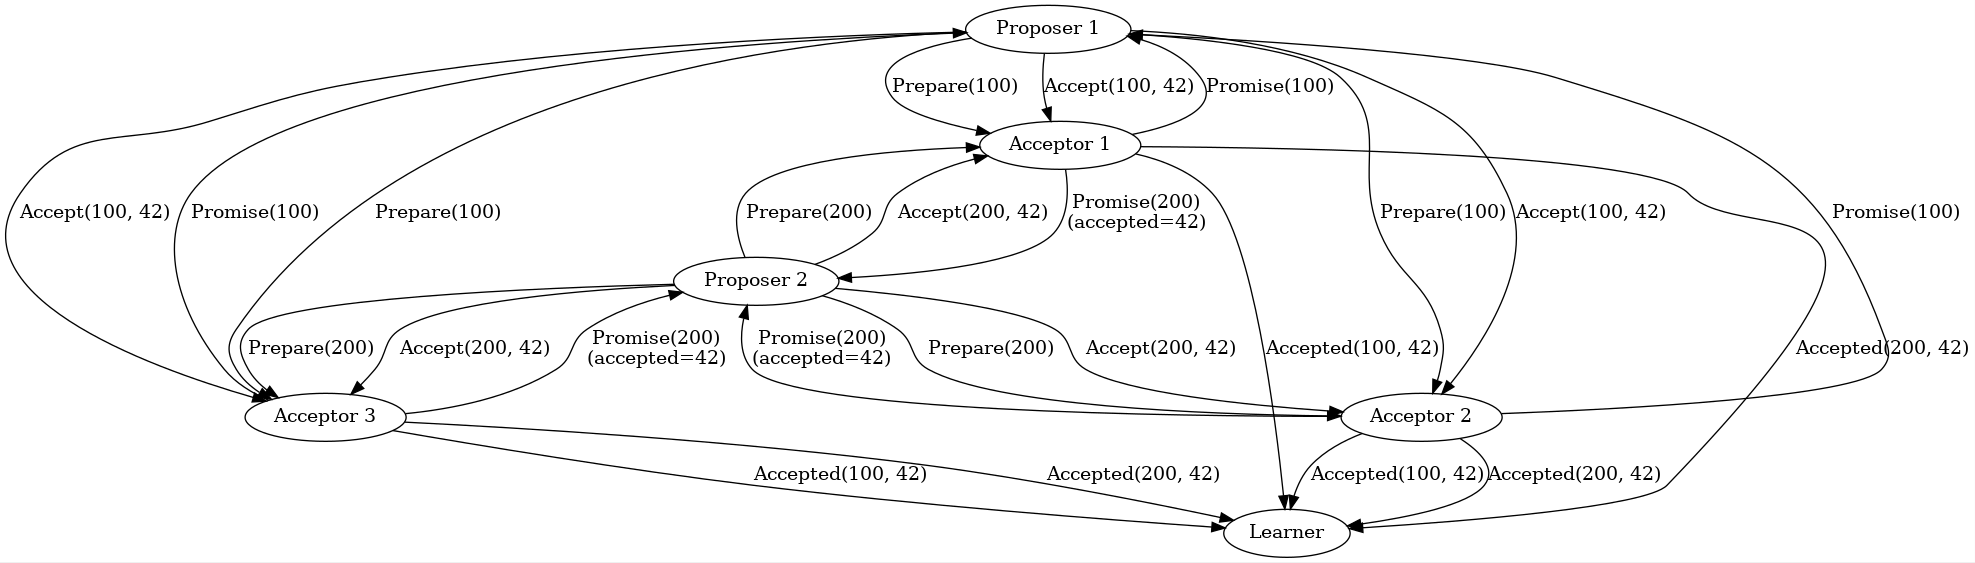


## 📖 Description

In this scenario, two proposers initiate the Paxos protocol at nearly the same time, but with different proposal IDs. The key rule in Paxos is that **only one value can be chosen** even under concurrent attempts, and **higher proposal IDs are prioritized** when resolving conflicts.

---

## 🧠 Step-by-Step Execution:

1. **Proposer 1** starts with proposal ID `100` and sends `Prepare(100)` to acceptors.
2. Almost simultaneously, **Proposer 2** starts with proposal ID `200` and sends `Prepare(200)`.
3. Since `200 > 100`, all acceptors promise to Proposer 2.
4. Proposer 2 receives a majority of promises and sends `Accept(200, 84)` (no prior value was accepted).
5. All acceptors accept the value `84`, and consensus is achieved.
6. Proposer 1 fails to reach quorum and aborts.
